# 06 — Final Training, Evaluation & Export (Stage 2)

**Purpose:** Train the best configuration identified from ablation studies
(notebooks 04-05), run comprehensive evaluation, and export the model
for deployment.

**Outputs:**
- Final checkpoint (`.pth`)
- ONNX export (`.onnx`)
- TorchScript export (`.pt`)
- Comprehensive evaluation report (JSON + plots)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q yacs tqdm opencv-python-headless tensorboard onnx onnxruntime

import os, sys
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 232.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.9 MB/s eta 0:00:00


In [2]:
import os
import sys
REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)


import os
import sys
import json
import logging
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader

from lib.config import cfg
from lib.models import get_net
from lib.core import get_loss, validate
from lib.dataset import BddDataset
from lib.utils.drive_dataset import (
    ensure_local_dataset_from_drive,
    find_raw_bdd_root,
    resolve_bdd_images_100k_dir,
    resolve_bdd_labels_100k_dir,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Stage-1 default target: YOLOP baseline.
CONFIG = 'YOLOP'
CHECKPOINT_NAME = 'best_joint.pth'
RUN_EVAL = True
EXPORT_ONNX = True
EXPORT_TORCHSCRIPT = True

yaml_map = {
    'YOLOPv2-paper-no-da': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_paper_no_da.yaml'),
    'YOLOPv2-best-row': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_best_row.yaml'),
    'YOLOPv2-focal-only': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolopv2_focal_only_ablation.yaml'),
    'YOLOP': os.path.join(REPO_ROOT, 'stage1', 'configs', 'yolop_vehicle_lane_baseline.yaml'),
}
run_name_map = {
    'YOLOPv2-paper-no-da': 'yolopv2_paper_no_da',
    'YOLOPv2-best-row': 'yolopv2_best_row',
    'YOLOPv2-focal-only': 'yolopv2_focal_only',
    'YOLOP': 'yolop',
}

cfg.defrost()
cfg.merge_from_file(yaml_map[CONFIG])

ECOCAR_ROOT = '/content/drive/MyDrive/EcoCAR'
DATASET_ROOT = ensure_local_dataset_from_drive('bdd100k_vehicle5', ECOCAR_ROOT)
RAW_BDD_ROOT = find_raw_bdd_root(ECOCAR_ROOT)
BDD_IMAGES = resolve_bdd_images_100k_dir(RAW_BDD_ROOT)
BDD_LABELS = resolve_bdd_labels_100k_dir(RAW_BDD_ROOT)

cfg.DATASET.ROOT = DATASET_ROOT
cfg.DATASET.DATAROOT = BDD_IMAGES
cfg.DATASET.LABELROOT = BDD_LABELS
cfg.DATASET.LANEROOT = os.path.join(DATASET_ROOT, 'masks')

run_name = run_name_map[CONFIG]
cfg.DRIVE.CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'stage1', 'checkpoints', run_name)
cfg.DRIVE.METRICS_DIR = os.path.join(REPO_ROOT, 'stage1', 'metrics', run_name)
cfg.freeze()

checkpoint_candidates = [
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, CHECKPOINT_NAME),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'best_joint.pth'),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'best.pth'),
    os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'latest.pth'),
]
ckpt_path = None
for cand in checkpoint_candidates:
    if os.path.exists(cand):
        ckpt_path = cand
        break
assert ckpt_path is not None, f'No checkpoint found in {cfg.DRIVE.CHECKPOINT_DIR}'

model = get_net(cfg).to(device)
model.gr = 1.0
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

print(f'[{CONFIG}] checkpoint: {ckpt_path}')
print(f'  epoch={ckpt.get("epoch", "?")}  nc={model.nc}  names={model.names}')
print(f'  dataset_root={cfg.DATASET.ROOT}')
print(f'  val_image_size={tuple(cfg.TEST.IMAGE_SIZE)}')


Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_vehicle5.tar.gz into this notebook runtime ...
[YOLOP] checkpoint: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolop/best_joint.pth
  epoch=99  nc=1  names=['vehicle']
  dataset_root=/content/bdd100k_vehicle5
  val_image_size=(640, 640)


[Dataset] split=val | layout=explicit_packaged_like
[Dataset] images=/content/bdd100k_raw/100k/val
[Dataset] labels=/content/bdd100k_raw/100k/val
[Dataset] lanes =/content/bdd100k_vehicle5/masks/val
building database...


100%|██████████| 10000/10000 [00:00<00:00, 10493.09it/s]


database build finish: 10000 samples
missing lane masks skipped: 0
missing detection labels: 0


  0%|          | 0/417 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|██████████| 417/417 [01:15<00:00,  5.49it/s]


                 all       1e+04    1.08e+05      0.0608       0.893       0.754       0.427
Speed: 1.3/0.6/1.9 ms inference/NMS/total per 640x640 image at batch-size 16
Results saved to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolop/final_eval/visualization

STAGE-1 FINAL VALIDATION SUMMARY
{
  "config": "YOLOP",
  "checkpoint": "/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolop/best_joint.pth",
  "epoch": 99,
  "detection": {
    "precision": 0.060820206075237686,
    "recall": 0.8933661749647137,
    "mAP50": 0.7536526430639692,
    "mAP50_95": 0.4266560652786399
  },
  "lane": {
    "accuracy": 0.6911264952822688,
    "IoU": 0.22682176667997123,
    "mIoU": 0.608363724254489
  },
  "timing": {
    "inference_ms_per_image": 1.345137069965231,
    "nms_ms_per_image": 0.5829304862997488
  },
  "val_loss": 0.24818660751581192
}
Saved summary to: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolop/final_eval/yolop_best_joi

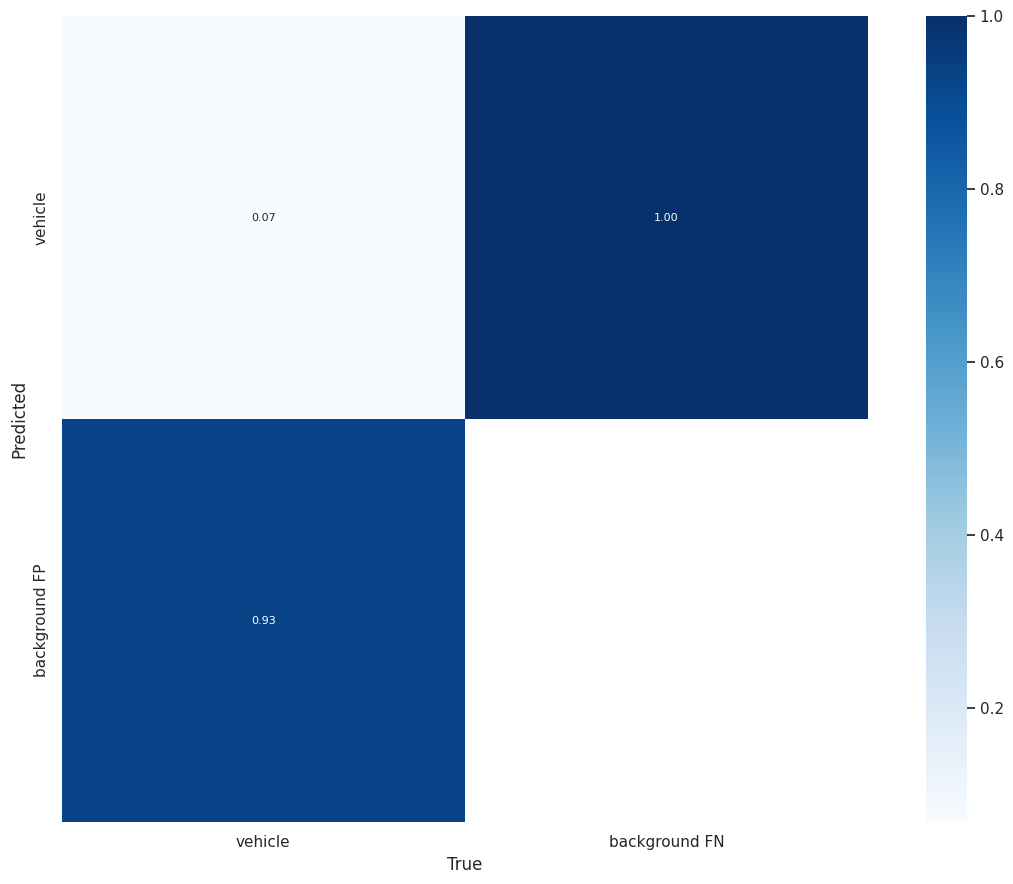

In [3]:

# ── Full validation first (stage-1 protocol) ──
eval_summary = None
if RUN_EVAL:
    val_wh = tuple(getattr(cfg.TEST, 'IMAGE_SIZE', [640, 384]))
    val_size = (int(val_wh[1]), int(val_wh[0]))

    val_dataset = BddDataset(cfg, is_train=False, inputsize=val_size, transform=T.ToTensor())
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg.TEST.BATCH_SIZE_PER_GPU,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=val_dataset.collate_fn,
    )

    logger = logging.getLogger(f'eval_{CONFIG}')
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        logger.addHandler(logging.StreamHandler())

    criterion = get_loss(cfg, device)
    output_dir = os.path.join(cfg.DRIVE.METRICS_DIR, 'final_eval')
    os.makedirs(output_dir, exist_ok=True)

    ll_seg_result, det_result, val_loss, maps, times = validate(
        epoch=ckpt.get('epoch', -1),
        config=cfg,
        val_loader=val_loader,
        val_dataset=val_dataset,
        model=model,
        criterion=criterion,
        output_dir=output_dir,
        tb_log_dir='',
        writer_dict=None,
        logger=logger,
        device=device,
    )

    ll_acc, ll_iou, ll_miou = ll_seg_result
    mp, mr, map50, map_all = det_result
    eval_summary = {
        'config': CONFIG,
        'checkpoint': ckpt_path,
        'epoch': int(ckpt.get('epoch', -1)),
        'detection': {
            'precision': float(mp),
            'recall': float(mr),
            'mAP50': float(map50),
            'mAP50_95': float(map_all),
        },
        'lane': {
            'accuracy': float(ll_acc),
            'IoU': float(ll_iou),
            'mIoU': float(ll_miou),
        },
        'timing': {
            'inference_ms_per_image': float(times[0] * 1000.0),
            'nms_ms_per_image': float(times[1] * 1000.0),
        },
        'val_loss': float(val_loss),
    }

    summary_path = os.path.join(output_dir, f'{CONFIG.lower()}_{os.path.basename(ckpt_path).replace(".pth", "")}_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(eval_summary, f, indent=2)

    print('\n' + '=' * 70)
    print('STAGE-1 FINAL VALIDATION SUMMARY')
    print('=' * 70)
    print(json.dumps(eval_summary, indent=2))
    print(f'Saved summary to: {summary_path}')


In [4]:

import os

try:
    import onnxscript
except ImportError:
    print('onnxscript not found. Installing...')
    !pip install -q onnxscript
    import onnxscript

class DemoExportWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        det_out, lane_prob = self.m.predict(x)
        if isinstance(det_out, (tuple, list)):
            det_export = det_out[0] if isinstance(det_out, tuple) else det_out[0]
        else:
            det_export = det_out
        return det_export, lane_prob

export_model = DemoExportWrapper(model).to(device).eval()
export_dir = os.path.join(cfg.DRIVE.CHECKPOINT_DIR, 'exports')
os.makedirs(export_dir, exist_ok=True)

dummy_input = torch.randn(1, 3, 640, 640, device=device)

if EXPORT_ONNX:
    onnx_path = os.path.join(export_dir, f'{CONFIG.lower()}_{os.path.basename(ckpt_path).replace(".pth", "")}.onnx')
    torch.onnx.export(
        export_model,
        dummy_input,
        onnx_path,
        opset_version=18,
        input_names=['images'],
        output_names=['det_out', 'lane_prob'],
        dynamic_axes={
            'images': {0: 'batch'},
            'det_out': {0: 'batch'},
            'lane_prob': {0: 'batch'},
        },
    )
    import onnx
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print(f'ONNX exported to {onnx_path}')

if EXPORT_TORCHSCRIPT:
    ts_path = os.path.join(export_dir, f'{CONFIG.lower()}_{os.path.basename(ckpt_path).replace(".pth", "")}.pt')
    traced = torch.jit.trace(export_model, dummy_input, strict=False, check_trace=False)
    traced.save(ts_path)
    print(f'TorchScript exported to {ts_path}')


onnxscript not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 21.5 MB/s eta 0:00:00


/tmp/ipykernel_10444/828155409.py:31: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0424 21:02:36.115000 10444 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0424 21:02:36.116000 10444 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0424 21:02:36.117000 10444 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scal

[torch.onnx] Obtain model graph for `DemoExportWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DemoExportWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0424 21:02:42.547000 10444 torch/onnx/_internal/exporter/_core.py:1248] Tensor 'm.model.24.stride' is not one of the initializers


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX exported to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolop/exports/yolop_best_joint.onnx


/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/lib/models/common.py:201: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if self.grid[i].shape[2:4] != x[i].shape[2:4]:


TorchScript exported to /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolop/exports/yolop_best_joint.pt


In [5]:

# ── Model size summary ──
param_count = sum(p.numel() for p in model.parameters())
ckpt_size_mb = os.path.getsize(ckpt_path) / 1024 / 1024
print(f'Parameters:     {param_count / 1e6:.2f} M')
print(f'Checkpoint:     {ckpt_size_mb:.1f} MB')
print(f'Checkpoint dir: {cfg.DRIVE.CHECKPOINT_DIR}')
print(f'Metrics dir:    {cfg.DRIVE.METRICS_DIR}')
if RUN_EVAL and eval_summary is not None:
    print(f"Eval mAP@0.5:   {eval_summary['detection']['mAP50']:.4f}")
    print(f"Eval lane IoU:  {eval_summary['lane']['IoU']:.4f}")


Parameters:     7.60 M
Checkpoint:     87.4 MB
Checkpoint dir: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/checkpoints/yolop
Metrics dir:    /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage1/metrics/yolop
Eval mAP@0.5:   0.7537
Eval lane IoU:  0.2268
